In [1]:
import sys, glob, os, yaml, sparse, tracemalloc, vcf, subprocess, collections
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import scipy.stats as st
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler

from dna_features_viewer import BiopythonTranslator, GraphicFeature, GraphicRecord
from dna_features_viewer.biotools import annotate_biopython_record
import itertools, difflib

import warnings
warnings.filterwarnings("ignore")

# utils files are in a separate folder
os.chdir("../")
sys.path.append("utils")
from data_utils import *

who_variants = pd.read_csv("./data_processing/data_utils/WHO_catalog_V2.csv", header=[2]).reset_index(drop=True)
data_dir = "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs"
results_dir = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"

import Bio.SeqUtils
from Bio import Seq, SeqIO
from functools import reduce

model_loci = pd.read_csv("./data_processing/data_utils/drug_loci.csv")
cc_df = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/criticalConcentrations_updated.csv")

drug_abbr_dict = {"Delamanid": "DLM",
                  "Bedaquiline": "BDQ",
                  "Clofazimine": "CFZ",
                  "Ethionamide": "ETH",
                  "Linezolid": "LZD",
                  "Moxifloxacin": "MXF",
                  "Capreomycin": "CAP",
                  "Amikacin": "AMI",
                  "Pretomanid": "PTM",
                  "Pyrazinamide": "PZA",
                  "Kanamycin": "KAN",
                  "Levofloxacin": "LEV",
                  "Streptomycin": "STM",
                  "Ethambutol": "EMB",
                  "Isoniazid": "INH",
                  "Rifampicin": "RIF"
                 }

abbr_drug_dict = {val: key for (key, val) in drug_abbr_dict.items()}

lineages = pd.read_csv("data_processing/samples_pass_geno_QC.csv")

# for i, row in lineages.iterrows():
#     if row['Coll2014'][0].isnumeric():
#         lineages.loc[i, 'Lineage'] = row['Coll2014'][0]
#     else:
#         lineages.loc[i, 'Lineage'] = row['Coll2014']
        
cc_dict = {'RIF': 0.5, 'INH': 0.2, 'EMB': 5, 'PZA': 100, 'ETH': 5, 'MXF': 0.5, 'LEV': 1, 'BDQ': 0.25, 'LZD': 1, 'CFZ': 1, 'DLM': 0.016}

# Train vs. Test vs. Validation MIC Distributions (ECDFs FOR SUPPLEMENT)

In [6]:
def compare_three_distributions_ecdf(drug, cc, log_base=2, save=False):
    
    df_combined = pd.read_csv(os.path.join(data_dir, drug, "data_for_model.csv")).query("Span_CC==0")
    df_combined.rename(columns={"category": "Dataset"}, inplace=True)

    df_combined["Dataset"] = df_combined["Dataset"].replace("train_set", "Train").replace("test_set", "Test").replace('validation_set', 'Validation')
    hue_order = ["Train", "Test"] #"Validation", "Test"]
    
    fig, ax = plt.subplots()
    
    # sns.ecdfplot(data=df_combined,
    #              x=f"{drug}_midpoint",
    #              hue="Dataset",
    #              hue_order=hue_order,
    #              log_scale=log_base,
    #              ax=ax,
    #              palette="colorblind"
    #             )

    # # ax.set_yticks(ticks=ax.get_yticks(), labels=(ax.get_yticks()*100).astype(int))
    # ax.set_yticks(ticks=[0.25, 0.5, 0.75, 1], labels=[25, 50, 75, 100])

    # for percentile in [0.25, 0.5, 0.75]:
    #     plt.axhline(y=percentile, linestyle='--', color="lightgray", linewidth=1, zorder=0)

    sns.histplot(data=df_combined,
             x=f"{drug}_midpoint",
             hue="Dataset",
             hue_order=hue_order,
             log_scale=log_base,
             ax=ax,
             palette="colorblind",
                 stat='probability',
                 common_norm=False,
                 multiple='dodge'
            )

    plt.xlabel(f"{abbr_drug_dict[drug]} MIC (µg/mL)")
    # plt.ylabel("Percentile")
        
    # Get the handles and labels from both legends
    handles, labels = plt.gca().get_legend().legendHandles, [t.get_text() for t in plt.gca().get_legend().get_texts()]
    
    # Add a legend that combines the handles and labels
    plt.legend(handles=handles + [plt.axvline(cc, color="black", linestyle="dashed", label=f"CC = {cc}")], labels=labels + [f"CC = {cc}"])
    # sns.move_legend(ax, loc="lower right")
    sns.despine()
    
    if save:
        if not os.path.isdir(f"./results/{abbr_drug_dict[drug]}"):
            os.mkdir(f"./results/{abbr_drug_dict[drug]}")
            
        plt.savefig(f"./results/{abbr_drug_dict[drug]}/MIC_ECDF.svg")
    else:
        plt.show()
        
    # print p-value for difference between distributions using Kolmogorov-Smirnov test, which is non-parametric
    _, pval = st.ks_2samp(np.log2(df_combined.query("Dataset in ['Train', 'Validation']")[f"{drug}_midpoint"]),
                          np.log2(df_combined.query("Dataset=='Test'")[f"{drug}_midpoint"]),
                          alternative='two-sided'
                         )

    prop_resistant = df_combined.Binary.mean()
    
    print(f"{drug}: N = {len(df_combined)}, pval for Train/Test: {np.round(pval, 4)}, R = {np.round(prop_resistant, 3)*100}%")

BDQ: N = 9080, pval for Train/Test: 0.8702, R = 1.2%
EMB: N = 9757, pval for Train/Test: 0.6614, R = 27.3%
ETH: N = 10710, pval for Train/Test: 1.0, R = 16.900000000000002%
INH: N = 11837, pval for Train/Test: 0.9832, R = 54.50000000000001%
LEV: N = 8490, pval for Train/Test: 0.9986, R = 18.7%
MXF: N = 9206, pval for Train/Test: 0.9825, R = 18.4%
PZA: N = 913, pval for Train/Test: 0.9996, R = 52.6%
RIF: N = 11206, pval for Train/Test: 0.992, R = 48.6%


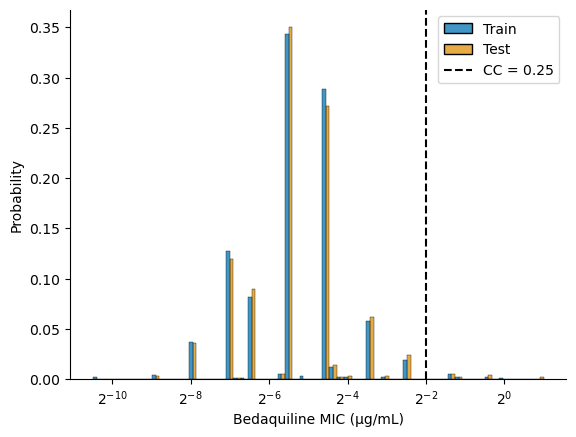

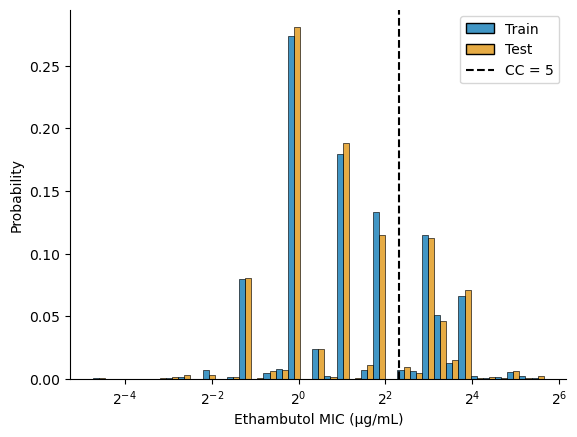

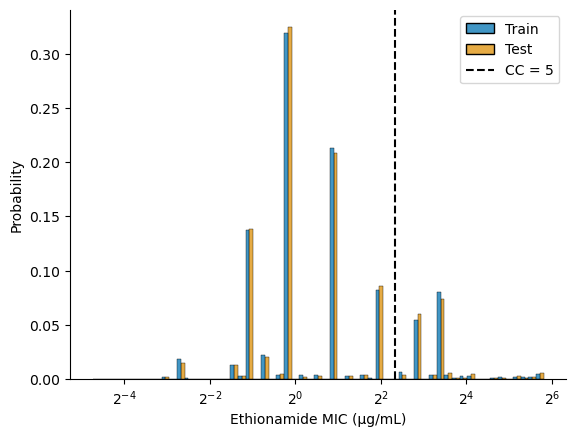

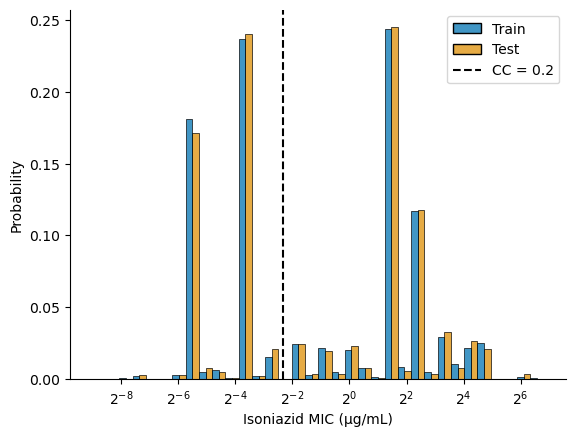

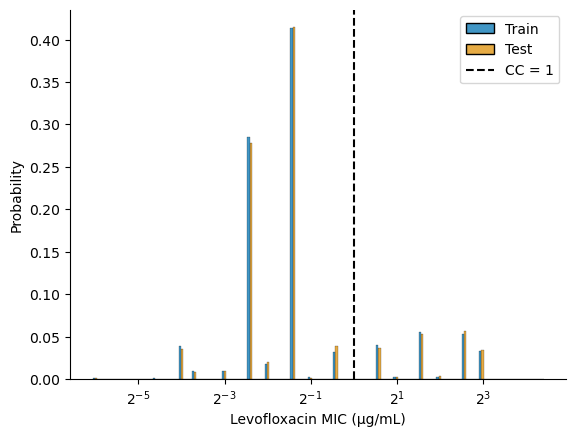

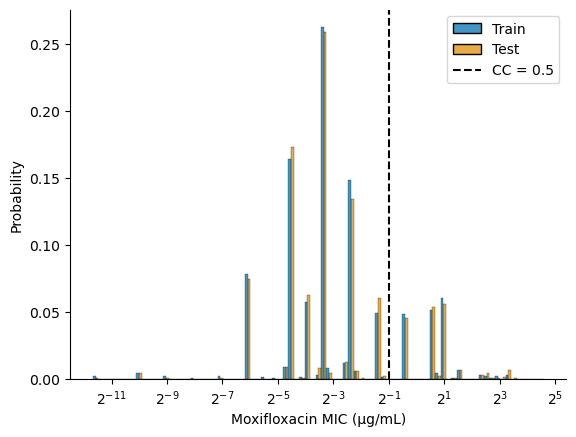

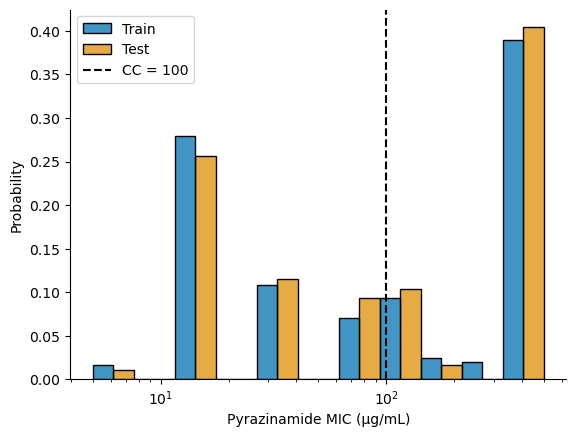

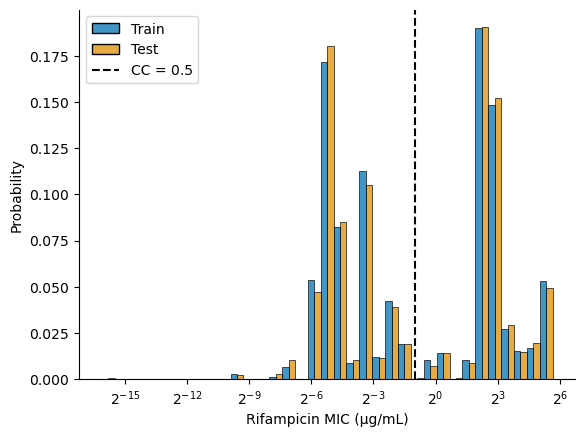

In [8]:
for drug in np.sort(os.listdir(data_dir)):

    if drug == 'PZA':
        log_base = 10
    else:
        log_base = 2

    compare_three_distributions_ecdf(drug, cc_dict[drug], log_base=log_base, save=True)

# Min, Max, Average MICs

In [24]:
for drug in np.sort(os.listdir(data_dir)):

    df_combined = pd.read_csv(os.path.join(data_dir, drug, "data_for_model.csv")).query("Span_CC==0")

    unique_MIC = np.sort(df_combined[f'{drug}_upper_bound'])

    assert np.sort(np.unique(df_combined[f'{drug}_lower_bound']))[0] == 0
    # assert np.sort(np.unique(df_combined[f'{drug}_upper_bound']))[-1] == np.inf
    
    # print(drug, np.sort(np.unique(df_combined[f'{drug}_lower_bound']))[1], np.sort(np.unique(df_combined[f'{drug}_upper_bound']))[-2])

    print(drug, np.sort(np.unique(df_combined[f'{drug}_upper_bound']))[-2], np.mean(df_combined[f'{drug}_midpoint']))

BDQ 2.0 0.04069462190253304
EMB 64.0 4.228203305317515
ETH 64.0 3.1395976349206354
INH 128.0 3.0433089238022024
LEV 32.0 1.0799998233215546
MXF 32.0 0.4558932132933044
PZA 500.0 224.1812705366922
RIF 50.0 5.721503513655853


In [28]:
model_loci.query("Locus in ['atpE', 'pepQ', 'Rv0678', 'mmpLS5', 'aftB-ubiA', 'aftA-embCAB', 'fabG1-inhA', 'mshA', 'ahpC', 'kasA', 'katG-furA', 'gyrBA', 'rpsA', 'pncA', 'panD', 'clpC1', 'rpoBC', 'ethA', 'ethR']").sort_values('Start').to_csv("supplement/model_loci.csv", index=False)

# Lineage Distributions

In [9]:
def get_lineage_summary(fName):

    df = pd.read_csv(fName)

    # already merged with the training set so that we could stratify the train/test sets by binary phenotype and primary lineage
    # so remove them
    if "Lineage" in df.columns:
        del df["Coll2014"]
        del df["Lineage"]
        
    df = df.merge(lineages, on="ROLLINGDB_ID", how="left")    
    assert len(df.loc[pd.isnull(df["Lineage"])]) == 0

    # df["Lineage"] = df["Lineage"].str.replace('5', 'Other')
    # df["Lineage"] = df["Lineage"].str.replace('6', 'Other')

    # very rare
    df.loc[df["Lineage"].str.contains('|'.join(['BOV', '5', '6'])), 'Lineage'] = 'Other'

    df_summary = df["Lineage"].value_counts().reset_index()
    df_summary.columns = ["Lineage", "Count"]
    df_summary = df_summary.sort_values("Lineage", ascending=True).reset_index(drop=True)
    df_summary["Lineage"] = df_summary["Lineage"].astype(str)
    
    return df_summary
    
    
    
def create_stacked_percent_bar_chart(drugs_lst, saveName=None):
    
    # LinToColor_Dict = {"1": "#f381b2",
    #                    "2": "#006dbb",
    #                    "3": "#9f5eab",
    #                    "4": "#f6472b",
    #                    "5": "#76400e",
    #                    "M. bovis": "white"
    #                   }

    LinToColor_Dict = {"1": "#DF83AC",
                       "2": "#7098CB",
                       "3": "#815D9F",
                       "4": "#E76956",
                       "Other": "white"
                       # "5": "#B67548",
                       # "6": "#6AB79E",
                       # "8": "#E4515B",
                       # "M.bovis": "white",
                      }

    df_lineage_summaries = pd.DataFrame(columns=["Lineage", "Count"])
        
    for drug in np.sort(drugs_lst):
        df_summary = get_lineage_summary(os.path.join(data_dir, drug, "data_for_model.csv"))

        if drug == 'ETH':
            df_summary["Drug"] = 'ETO'
        elif drug == 'LEV':
            df_summary["Drug"] = 'LFX'
        else:
            df_summary["Drug"] = drug
            
        df_lineage_summaries = pd.concat([df_lineage_summaries, df_summary])

    drugs_lst = pd.Series(drugs_lst).str.replace('ETH', 'ETO').str.replace('LEV', 'LFX').values
    
    lineage_stacked_for_plotting = df_lineage_summaries.pivot(index="Drug", columns=["Lineage"], values="Count")
    lineage_stacked_for_plotting["Total"] = lineage_stacked_for_plotting.sum(axis=1)
    lineage_stacked_for_plotting = lineage_stacked_for_plotting.fillna(0)
    
    # compute proportions for plotting
    for lineage in lineage_stacked_for_plotting.columns:
        lineage_stacked_for_plotting[lineage] = lineage_stacked_for_plotting[lineage] / lineage_stacked_for_plotting["Total"] * 100
        
    del lineage_stacked_for_plotting["Total"]
    lineage_stacked_for_plotting = lineage_stacked_for_plotting.reset_index().melt(id_vars="Drug")
        
    # keep track of all the groups to increase the start value of the next bar
    prev_vals_array = np.zeros(len(lineage_stacked_for_plotting["Drug"].unique()))
    
    # order in increasing lineage abundance for each drug
    lineage_stacked_for_plotting = lineage_stacked_for_plotting.sort_values(["Drug", "value"], ascending=[True, False])
    
    # iterate through the Lineages and convert to percentages
    lineage_order = list(LinToColor_Dict.keys())[::-1] #lineage_stacked_for_plotting["Lineage"].unique()
    lineage_order = [val for val in lineage_order if val in lineage_stacked_for_plotting.Lineage.values]
    
    # set the figure size
    fig, ax = plt.subplots(figsize=(8, 5))
    
    for i, lineage in enumerate(lineage_order):  
                    
        # dataframe of proportion of each drug's samples that belong to the current lineage
        # MAKE SURE TO HAVE THE LOC.[DRUGS_LST] LINE IN BOTH SINGLE_GROUP AND PREV_VALS TO MAINTAIN THE DRUG ORDERING
        single_group = lineage_stacked_for_plotting[lineage_stacked_for_plotting["Lineage"]==lineage].groupby("Drug")["value"].sum().loc[drugs_lst].reset_index()
        
        if i > 0:
            prev_vals = lineage_stacked_for_plotting[lineage_stacked_for_plotting["Lineage"]==lineage_order[i-1]].groupby("Drug")["value"].sum().loc[drugs_lst].reset_index()
            prev_vals = prev_vals["value"].values
            prev_vals_array += prev_vals
            
        ax.bar(single_group['Drug'].values, 
               single_group["value"].values, 
               color=LinToColor_Dict[lineage], 
               bottom = prev_vals_array, 
               edgecolor="black",
               label=lineage,
               width=0.7
              )        

    label_loc = 'center'
    sigfig = 1
    font_size = '10'
    
    for cont in ax.containers:
        
        labels = []
        
        for val in cont.datavalues:
            if val >= 10:
                labels.append(int(np.round(val)))
            elif val >= 1:
                labels.append(np.round(val, sigfig))
            else:
                labels.append("")
                
        ax.bar_label(cont, labels=labels, label_type=label_loc, fontsize=font_size)
    
    plt.ylabel("Percent (%)")
    plt.setp(ax.patches, linewidth=0.75)
    sns.despine()
    
    # bar_scale = 0.85
    # for patch in ax.patches:
    #     current_width = patch.get_width()
    #     patch.set_width(current_width * bar_scale)
    
    # Rearrange the handles and labels
    handles, labels = ax.get_legend_handles_labels()    
    handles_labels_dict = dict(zip(labels, handles))
    handles_labels_dict = {key: val for key, val in handles_labels_dict.items() if key in lineage_order}
    handles_labels_dict = collections.OrderedDict(sorted(handles_labels_dict.items()))

    # Create the legend with the rearranged handles and labels
    ax.legend(list(handles_labels_dict.values()), list(handles_labels_dict.keys()))
    sns.move_legend(ax, fontsize=8, title='Lineage', loc='upper right',
                    ncol=1,#len(lineage_order),
                   #bbox_to_anchor=(0.85, -0.08),
                   bbox_to_anchor=(1.12, 0.6)
    )

    if saveName is not None:
        plt.savefig(saveName, format='svg', bbox_inches='tight')
    else:
        plt.show()

    return df_lineage_summaries

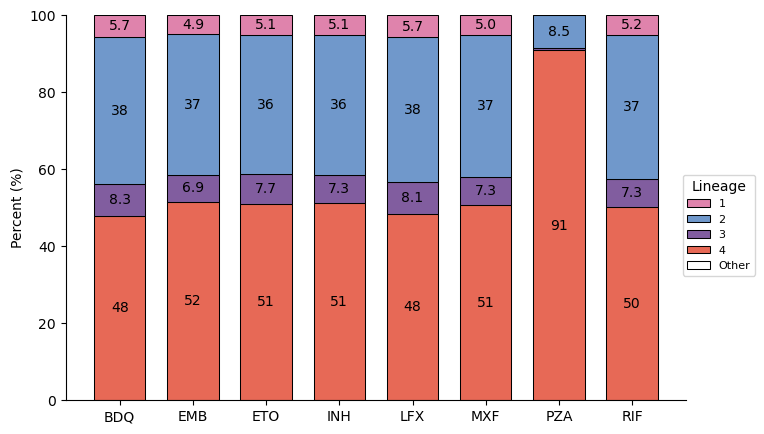

In [11]:
all_drug_lineages = create_stacked_percent_bar_chart(os.listdir(data_dir), saveName="results/lineage_summary_all_drugs.svg")

# Distribution of MIC vs. Unique Sequences

In [165]:
def make_boxplot_MIC_by_seq(drug, cc, log_base=2, isolate_thresh=30, saveFig=False):

    df = pd.read_csv(os.path.join(data_dir, drug, "data_for_model.csv"))
    df = df[["ROLLINGDB_ID", f"{drug}_midpoint", "Lineage"]]
    fasta_files = glob.glob(os.path.join(data_dir, drug, "fastas", "*.fasta"))
    
    combined_seq_df = []
    
    for fName in fasta_files:
        fasta_seq = [(seq.id.split(".")[0], str(seq.seq)) for seq in SeqIO.parse(fName, "fasta")]
        seq_df = pd.DataFrame(fasta_seq)
        seq_df.columns = ["ROLLINGDB_ID", os.path.basename(fName).split(".")[0]]
        combined_seq_df.append(seq_df)
    
    combined_seq_df = reduce(lambda x, y: pd.merge(x, y, on = 'ROLLINGDB_ID'), combined_seq_df).set_index('ROLLINGDB_ID')
    
    # string concatenate (join) all loci
    combined_seq_df = pd.DataFrame(combined_seq_df.apply(''.join, axis=1))
    combined_seq_df.columns = ['Seq']
    combined_seq_df = combined_seq_df.reset_index()

    # combine phenotypes and lineages with the concatenated sequences
    df = combined_seq_df.merge(df, on="ROLLINGDB_ID", how="inner")
    print(df.shape)
    
    seq_num_mapping = dict(zip(df.Seq.unique(), np.arange(len(df.Seq.unique())).astype(str)))
    df["Seq_Num"] = df["Seq"].map(seq_num_mapping)

    _, seq_counts = np.unique(df["Seq_Num"], return_counts=True)
    print(len(seq_counts), np.max(seq_counts))

    plot_df = df.groupby('Seq_Num').filter(lambda x: len(x) > isolate_thresh)
    print(len(plot_df))
    # plot_df["log2_MIC"] = np.log2(plot_df[f"{drug}_midpoint"])
    seq_num_order = plot_df.groupby("Seq_Num")[f"{drug}_midpoint"].mean().sort_values(ascending=True).index.values
    
    fig, ax = plt.subplots(1, 1, figsize=(20, 6))
    
    width = 0.75

    # if isolate_thresh > 10:
    sns.boxplot(data=plot_df,
                x="Seq_Num",
                y=f"{drug}_midpoint",
                log_scale=log_base,
                order=seq_num_order,
                fliersize=3,
                linewidth=width,
                color="cornflowerblue",
                boxprops={"edgecolor": "black", "linewidth": width},
                medianprops={"color": "black", "linewidth": width},
                whiskerprops={"color": "black", "linewidth": width},
                capprops={"color": "black", "linewidth": width},
                flierprops={"markerfacecolor": "black", "markeredgecolor": "black"},
                ax=ax
                )
    
    plt.xticks([], [])
    plt.axhline(y=cc, color="tomato", linewidth=1, linestyle="--", label=f"CC = {cc} µg/mL", zorder=1)
    
    plt.legend(loc="lower right")
    plt.xlabel("")
    plt.ylabel("MIC (µg/mL)")
    sns.despine()
    plt.title(f"{drug} MICs for {len(plot_df.Seq_Num.unique())} Unique Concatenated {len(fasta_files)}-Loci Sequences with at least {isolate_thresh} Isolates")

    if saveFig:
        plt.savefig(f"../analysis/{drug}/boxplot_MICS_by_seq.png", dpi=300, bbox_inches='tight')
    else:
        plt.show()

    return plot_df

(9001, 4)
1935 1097
5015


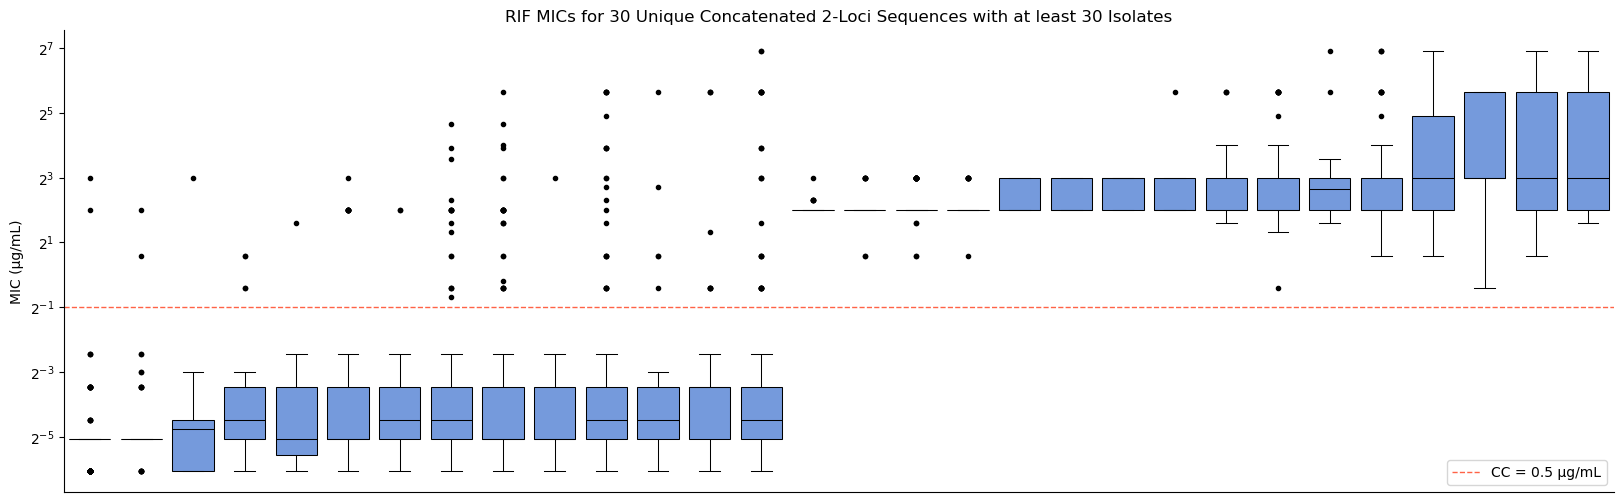

In [166]:
df_RIF_by_seq = make_boxplot_MIC_by_seq("RIF",
                                        cc=0.5,
                                        isolate_thresh=30,
                                        saveFig=True,
                                       )

(1015, 4)
345 185
570


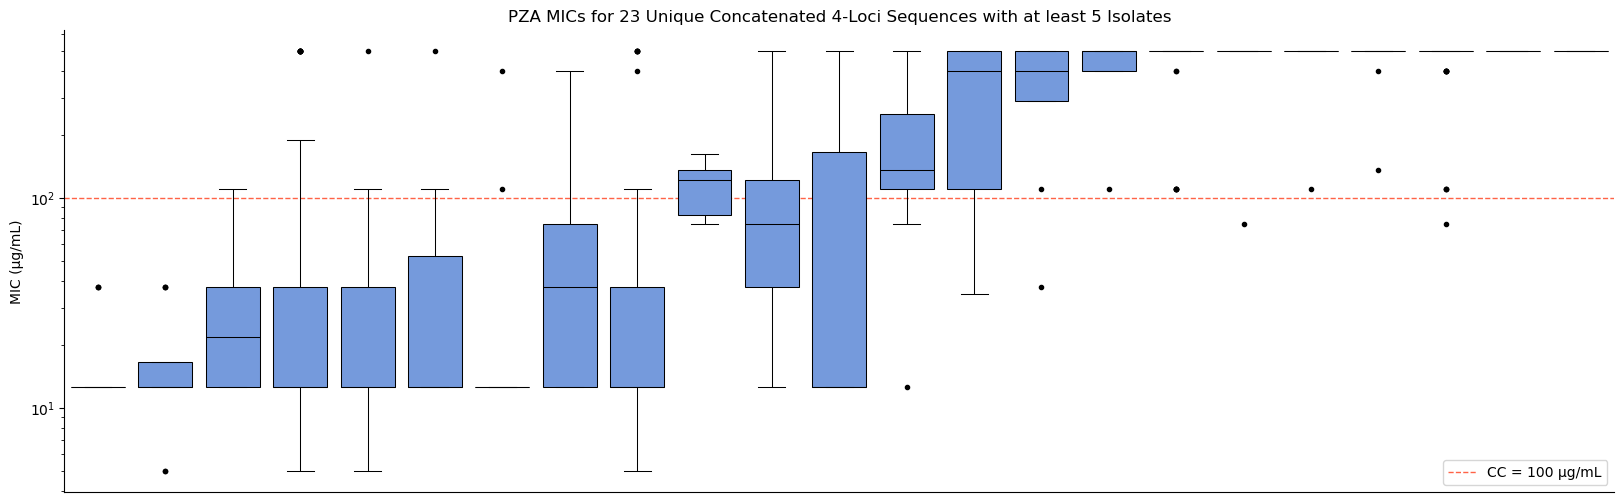

In [167]:
df_PZA_by_seq = make_boxplot_MIC_by_seq("PZA",
                                        cc=100,
                                        log_base=10,
                                        isolate_thresh=5,
                                        saveFig=True,
                                       )

(7000, 4)
847 3333
5541


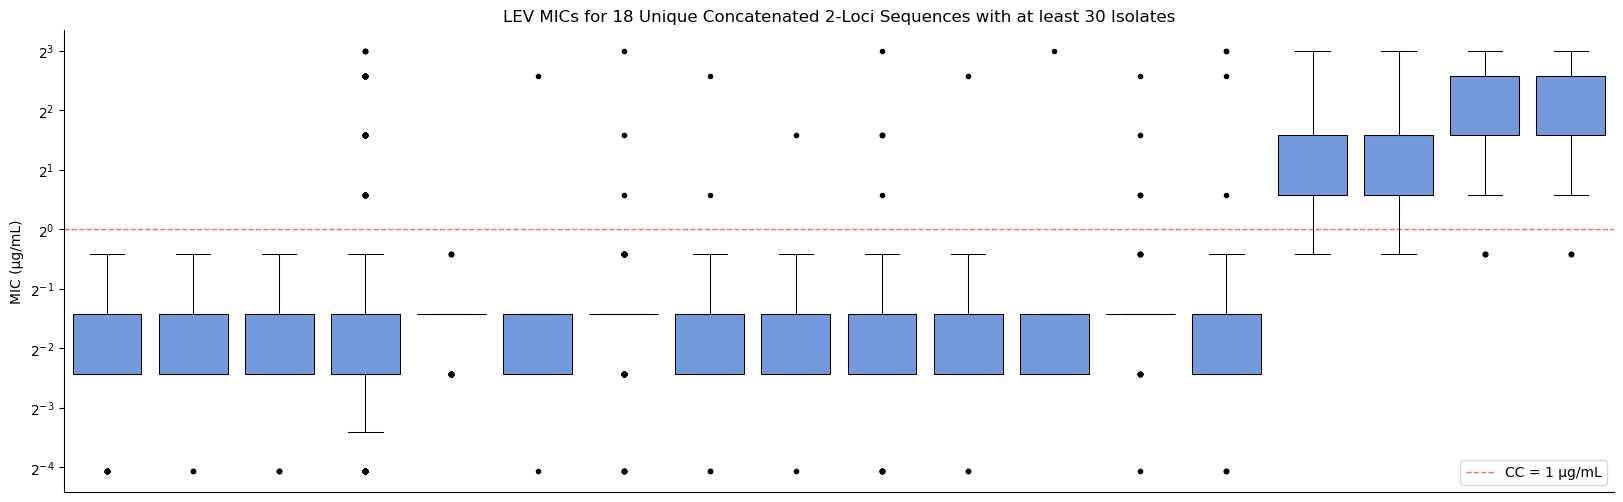

In [168]:
df_LEV_by_seq = make_boxplot_MIC_by_seq("LEV",
                                        cc=1,
                                        isolate_thresh=30,
                                        saveFig=True,
                                       )

(7354, 4)
855 3487
5827


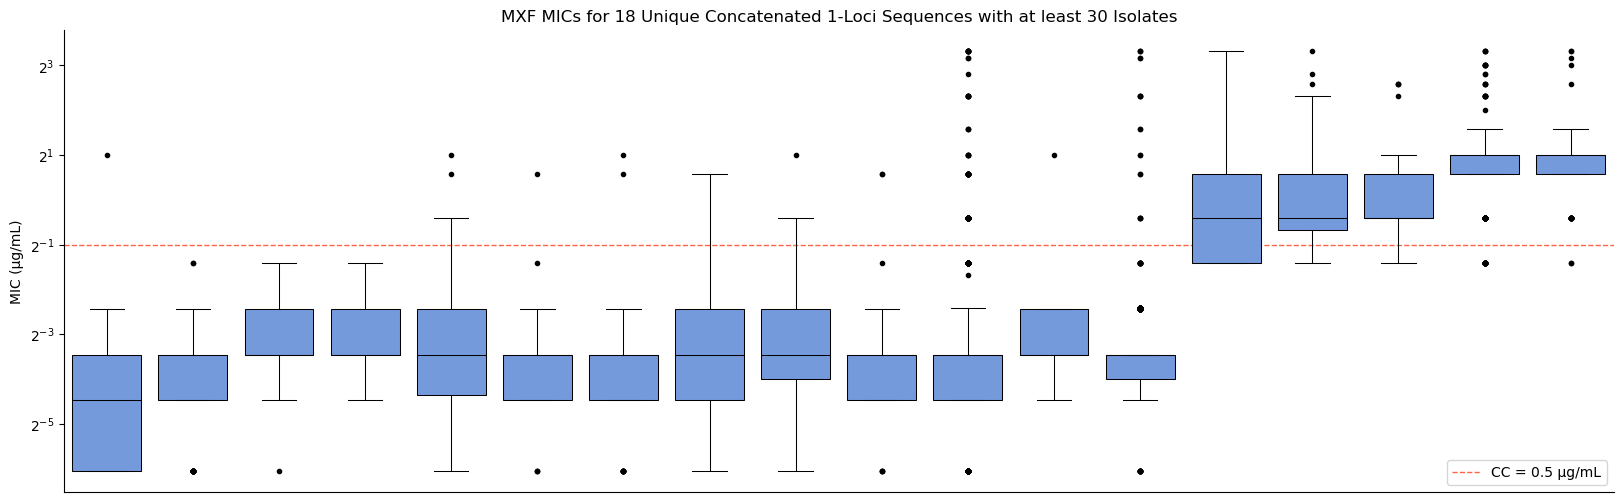

In [169]:
df_MXF_by_seq = make_boxplot_MIC_by_seq("MXF",
                                        cc=0.5,
                                        isolate_thresh=30,
                                        saveFig=True,
                                       )

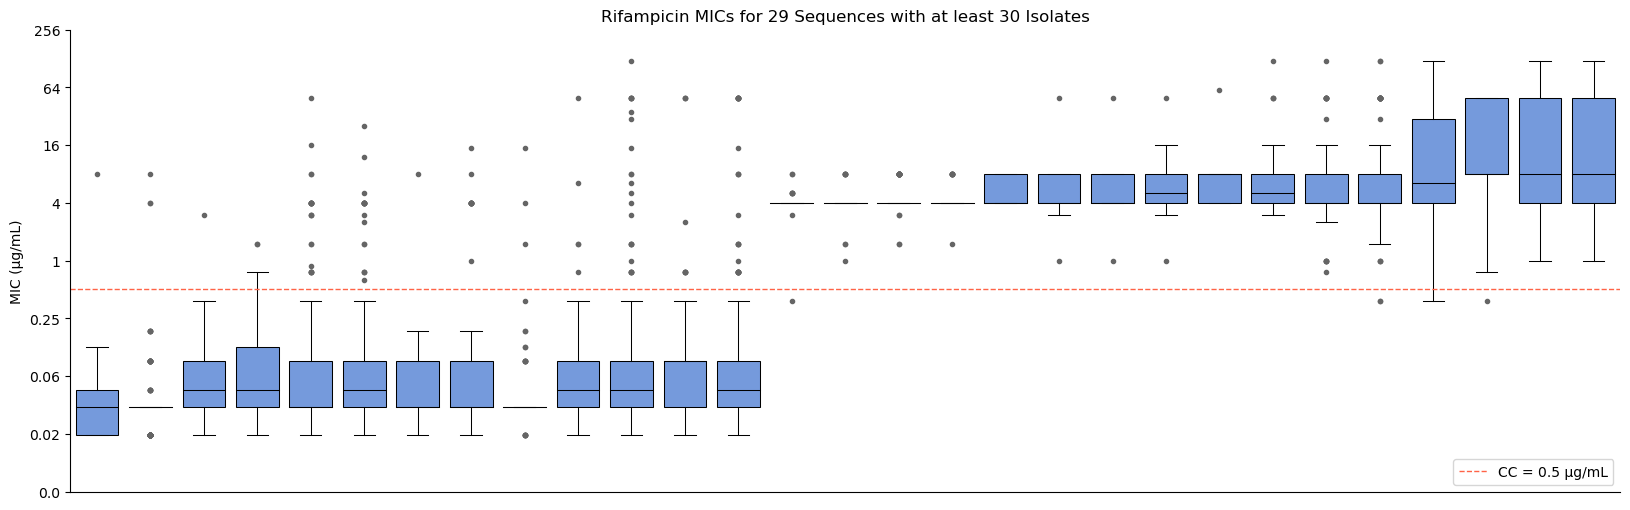

In [34]:
thresh = 30
plot_df = df_rif.groupby('Seq_Num').filter(lambda x: len(x) > thresh)
plot_df["log2-MIC"] = np.log2(plot_df["RIF_midpoint"])

# seq_num_order = plot_df['Seq_Num'].value_counts().to_frame().index.values.astype(str)
seq_num_order = plot_df.groupby("Seq_Num")["RIF_midpoint"].mean().sort_values(ascending=True).index.values

fig, ax = plt.subplots(1, 1, figsize=(20, 6))

width = 0.75

sns.boxplot(data=plot_df,
              x="Seq_Num",
              y="log2-MIC",
              order=seq_num_order,
              fliersize=3,
                linewidth=width,
              dodge=True,
            # jitter=True,
              color="cornflowerblue",
            boxprops={"edgecolor": "black", "linewidth": width},
            medianprops={"color": "black", "linewidth": width},
            whiskerprops={"color": "black", "linewidth": width},
            capprops={"color": "black", "linewidth": width},
             flierprops={"marker": "o", "color": "black"},
              ax=ax
             )

# # weird looking because the MICs are discretized, so they just form levels
# sns.stripplot(data=plot_df,
#               x="Seq_Num",
#               y="log2-MIC",
#               size=4,
#               order=seq_num_order,
#               jitter=True,
#               #inner="box",
#               color="black",
#               alpha=0.5,
#               ax=ax
#              )


plt.xticks([], [])
new_labels = [int(np.exp2(val)) if np.exp2(val) >= 1 else np.round(np.exp2(val), 2) for val in ax.get_yticks()]
ax.set_yticks(ticks=ax.get_yticks(), labels=new_labels)
plt.axhline(y=np.log2(0.5), color="tomato", linewidth=1, linestyle="--", label="CC = 0.5 µg/mL")

plt.legend(loc="lower right")
plt.xlabel("")
plt.ylabel("MIC (µg/mL)")
sns.despine()
plt.title(f"Rifampicin MICs for {len(plot_df.Seq_Num.unique())} Sequences with at least {thresh} Isolates")
#plt.show()
plt.savefig("Rifampicin/boxplot_MICS_by_seq.png", dpi=300)

In [ ]:
dd